<a href="https://colab.research.google.com/github/saverin0/Advanced_Geospatial_Analysis/blob/main/02_raster_to_vector_grid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 · Raster data into a vector point grid

Thins the SRTM DSM with a stride, converts the kept pixel centres into a `GeoDataFrame` of points
carrying the elevation value, and plots them over the NUTS-1 boundaries.

In [ ]:
import io, os, math, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.plot import plotting_extent

DATA = Path("data")
DATA.mkdir(exist_ok=True)
FIG = Path("figures")
FIG.mkdir(exist_ok=True)


def read_preview(path, max_px=2000):
    """Read band 1 decimated so the longer side is <= max_px. Use this for plotting:
    imshow on the full 142-megapixel array needs several GB and kills small kernels."""
    with rasterio.open(path) as src:
        f = max(1, math.ceil(max(src.width, src.height) / max_px))
        arr = src.read(1, out_shape=(src.height // f, src.width // f),
                       resampling=Resampling.average, masked=True)
        return arr, plotting_extent(src)


def download(url, dest, unzip=False):
    """Download `url` to `dest` (file, or folder when unzip=True). Skips if already present."""
    dest = Path(dest)
    if dest.is_file() or (dest.is_dir() and any(dest.iterdir())):
        print("already present:", dest)
        return dest
    print("downloading:", url)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=600) as r:
        payload = r.read()
    if unzip:
        dest.mkdir(parents=True, exist_ok=True)
        zipfile.ZipFile(io.BytesIO(payload)).extractall(dest)
    else:
        dest.write_bytes(payload)
    print(f"saved: {dest}  ({len(payload) / 1e6:.1f} MB)")
    return dest

from rasterio.transform import xy
from shapely.geometry import Point

In [ ]:
# SRTM 30 m Digital Surface Model of Germany, published by OpenDEM (~90 MB zip).
SRTM_URL = "https://www.opendem.info/downloads/srtm_germany_dsm.zip"
download(SRTM_URL, DATA / "srtm_dsm", unzip=True)

raster_file = next((DATA / "srtm_dsm").rglob("*.tif"))
raster_file

already present: data\srtm_dsm


WindowsPath('data/srtm_dsm/srtm_germany_dsm.tif')

In [ ]:
# NUTS level-1 regions (2016, 1:1M, EPSG:4326) straight from Eurostat GISCO.
NUTS_URL = ("https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/"
            "NUTS_RG_01M_2016_4326_LEVL_1.geojson")
nuts_file = download(NUTS_URL, DATA / "NUTS_RG_01M_2016_4326_LEVL_1.geojson")

gdf_nuts1 = gpd.read_file(nuts_file)
gdf_nuts1.head()

gdf_nuts1 = gdf_nuts1[gdf_nuts1.CNTR_CODE == "DE"].copy()

already present: data\NUTS_RG_01M_2016_4326_LEVL_1.geojson


## Choose the sampling density

In [ ]:
sample_percent = 0.009      # keep ~0.009 % of pixels -> stride ~ 105
stride = max(1, int(round(math.sqrt(1 / (sample_percent / 100)))))
stride

105

## Build the point grid

In [ ]:
with rasterio.open(raster_file) as src:
    raster = src.read(1, masked=True)          # band 1, nodata pixels become masked
    transform = src.transform                  # affine: (row, col) -> (x, y)
    raster_crs = src.crs

valid_mask = ~np.ma.getmaskarray(raster)       # True = valid pixel

# Generate only the strided (row, col) pairs, then keep the valid ones.
# Memory-safe: np.where over all valid pixels would need ~2.3 GB of index arrays.
h, w = raster.shape
rows_s, cols_s = np.meshgrid(np.arange(0, h, stride), np.arange(0, w, stride), indexing="ij")
rows_s, cols_s = rows_s.ravel(), cols_s.ravel()
print(f"  Strided candidates          : {len(rows_s):,}")

keep = valid_mask[rows_s, cols_s]
rows, cols = rows_s[keep], cols_s[keep]

xs, ys = xy(transform, rows, cols, offset="center")   # pixel indices -> cell-centre coordinates

gdf_grid = gpd.GeoDataFrame(
    {"elev_m": raster.data[rows, cols].astype(float)},
    geometry=gpd.points_from_xy(xs, ys),
    crs=raster_crs,
)
print(f"  Rows in GeoDataFrame        : {len(gdf_grid):,}")

  Strided candidates          : 12,978
  Rows in GeoDataFrame        : 12,978


In [ ]:
gdf_grid.head(3)

,elev_m,geometry
0,0.0,POINT (5 56)
1,0.0,POINT (5.0875 56)
2,0.0,POINT (5.175 56)


The OpenDEM GeoTIFF has no nodata flag, so sea and the neighbouring countries are ordinary pixels
(sea is 0 m). Clip the points to the German NUTS-1 polygons to keep only what we care about.

In [ ]:
germany = gdf_nuts1.to_crs(gdf_grid.crs)
gdf_grid = gpd.clip(gdf_grid, germany)
print(f"  Points inside Germany       : {len(gdf_grid):,}")

  Points inside Germany       : 6,008


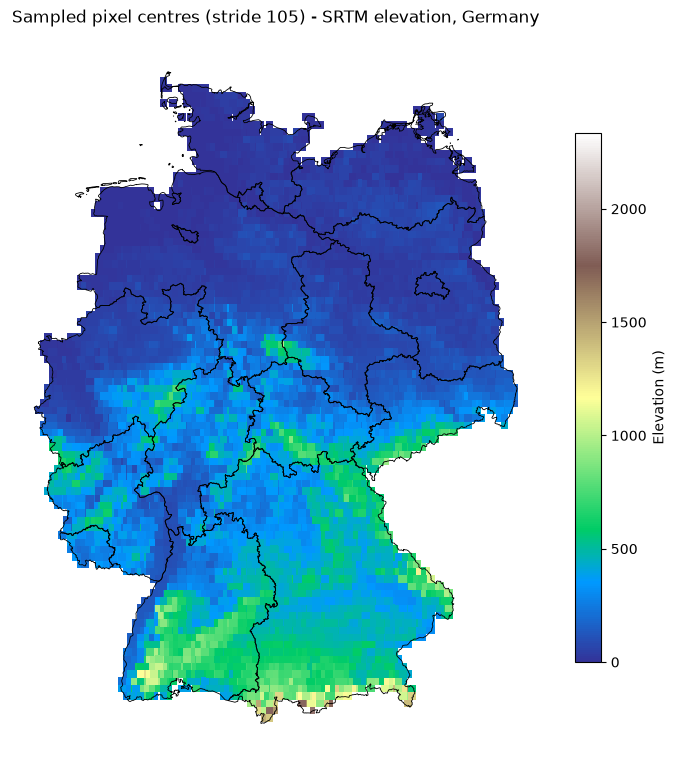

In [ ]:
fig, ax = plt.subplots(figsize=(7, 8))
germany.boundary.plot(ax=ax, linewidth=0.6, edgecolor="black", zorder=2)

sc = ax.scatter(gdf_grid.geometry.x, gdf_grid.geometry.y, s=32,
                c=gdf_grid["elev_m"], cmap="terrain", marker="s", linewidth=0, zorder=1)

plt.colorbar(sc, ax=ax, label="Elevation (m)", shrink=0.7)
ax.set_aspect(1 / math.cos(math.radians(51)))     # roughly equal-area look for lon/lat degrees
ax.set_title(f"Sampled pixel centres (stride {stride}) - SRTM elevation, Germany", pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG / "02_point_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## Save the grid

In [ ]:
out = DATA / "srtm_germany_points.gpkg"
gdf_grid.to_file(out, driver="GPKG")
print("saved", out, f"({out.stat().st_size / 1e6:.1f} MB)")

saved data\srtm_germany_points.gpkg (1.6 MB)
